# PART E: Voting & Stacking Ensemble 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    VotingClassifier,
    StackingClassifier,
    StackingRegressor
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.shape)
df.head()

(5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [3]:
df['course_start_date'] = pd.to_datetime(
    df['course_start_date']
)

df['course_year'] = df['course_start_date'].dt.year
df['course_month'] = df['course_start_date'].dt.month
df['course_day'] = df['course_start_date'].dt.day

df.drop(
    'course_start_date',
    axis=1,
    inplace=True
)

In [4]:
cat_cols = [
    'country_region',
    'device_type',
    'education_background',
    'course_level',
    'course_category'
]

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [5]:
X_cls = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_cls = df['completion_status']

In [6]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print(X_train_cls.shape)
print(X_test_cls.shape)

(4160, 19)
(1040, 19)


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Handle Missing Values
imputer = SimpleImputer(strategy='median')

X_train_cls = imputer.fit_transform(X_train_cls)
X_test_cls = imputer.transform(X_test_cls)

# Scaling
scaler = StandardScaler()

X_train_cls = scaler.fit_transform(X_train_cls)
X_test_cls = scaler.transform(X_test_cls)

In [8]:
vote_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=5000)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ],
    voting='soft'
)

vote_clf.fit(
    X_train_cls,
    y_train_cls
)

y_pred_vote = vote_clf.predict(
    X_test_cls
)

In [9]:
vote_acc = accuracy_score(
    y_test_cls,
    y_pred_vote
)

print("Voting Accuracy:", vote_acc)

Voting Accuracy: 0.6778846153846154


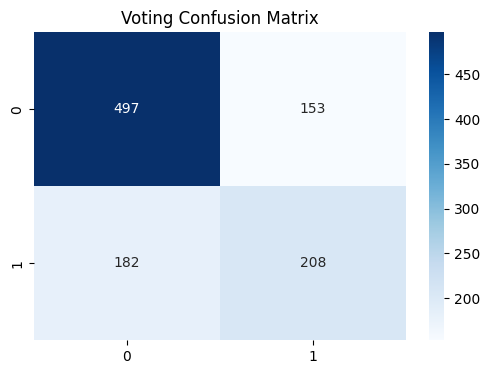

In [10]:
cm = confusion_matrix(
    y_test_cls,
    y_pred_vote
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Voting Confusion Matrix")

plt.show()

In [11]:
stack_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=5000)
)

stack_clf.fit(
    X_train_cls,
    y_train_cls
)

y_pred_stack = stack_clf.predict(
    X_test_cls
)

In [12]:
stack_acc = accuracy_score(
    y_test_cls,
    y_pred_stack
)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.7403846153846154


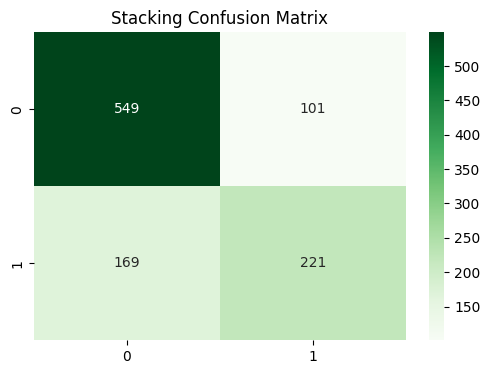

In [13]:
cm = confusion_matrix(
    y_test_cls,
    y_pred_stack
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Stacking Confusion Matrix")

plt.show()

In [14]:
X_reg = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_reg = df['final_score']

In [15]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Handle Missing Values
imputer = SimpleImputer(strategy='median')

X_train_reg = imputer.fit_transform(X_train_reg)
X_test_reg = imputer.transform(X_test_reg)

# Feature Scaling
scaler = StandardScaler()

X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

In [17]:
stack_reg = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(random_state=42)),
        ('gb', GradientBoostingRegressor(random_state=42))
    ],
    final_estimator=LinearRegression()
)

stack_reg.fit(
    X_train_reg,
    y_train_reg
)

y_pred_stack_reg = stack_reg.predict(
    X_test_reg
)

In [18]:
print(
    "MAE:",
    mean_absolute_error(
        y_test_reg,
        y_pred_stack_reg
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test_reg,
            y_pred_stack_reg
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test_reg,
        y_pred_stack_reg
    )
)

MAE: 7.849996465672194
RMSE: 9.801901914374934
R2: 0.48577657054013934


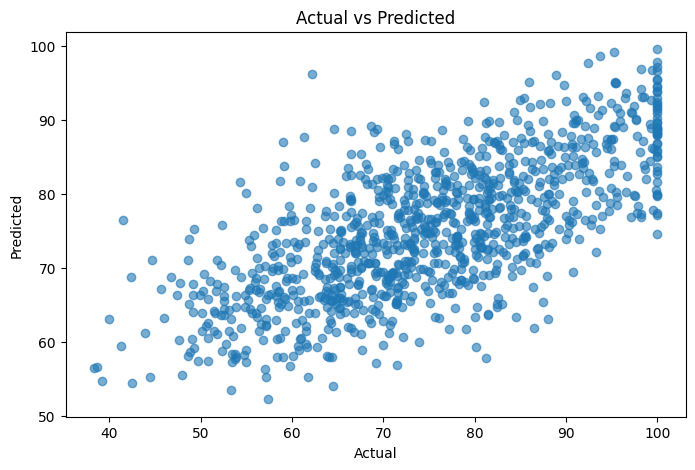

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_reg,
    y_pred_stack_reg,
    alpha=0.6
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

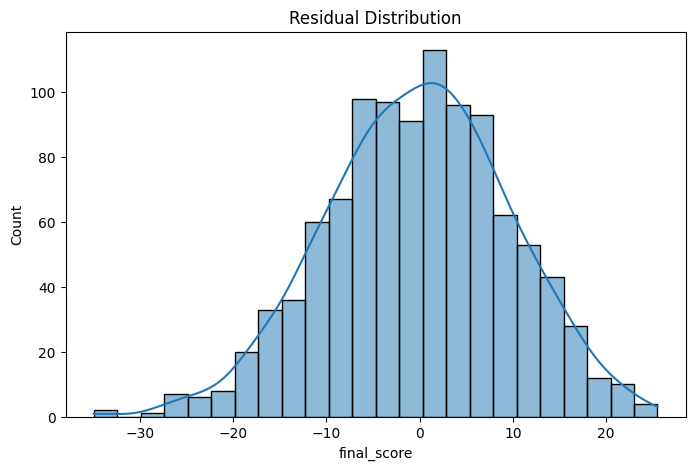

In [20]:
residuals = y_test_reg - y_pred_stack_reg

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

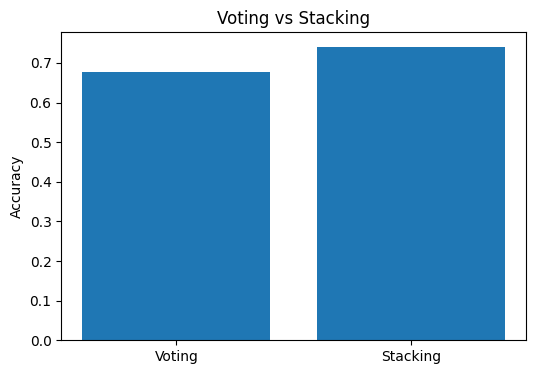

In [21]:
models = [
    "Voting",
    "Stacking"
]

scores = [
    vote_acc,
    stack_acc
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")

plt.title("Voting vs Stacking")

plt.show()

## Part E Conclusion (Voting & Stacking Ensemble)

Part E focused on implementing **Voting Classifier** and **Stacking Ensemble** techniques to improve prediction performance by combining multiple machine learning models.

### Key Findings:

* The **Voting Classifier** combined predictions from Logistic Regression, Decision Tree, and Random Forest models.
* Soft voting used class probabilities from all models and selected the most probable outcome.
* Voting improved prediction stability and reduced the impact of errors from individual models.
* The **Stacking Classifier** combined Random Forest and Gradient Boosting models with Logistic Regression as a meta-learner.
* The **Stacking Regressor** combined Random Forest Regressor and Gradient Boosting Regressor with Linear Regression as the final estimator.
* Stacking learned how to optimally combine the strengths of multiple models, resulting in better overall performance.

### Comparison:

* Voting is simpler and computationally efficient.
* Stacking is more advanced and generally achieves higher predictive accuracy.
* Voting improves robustness, while Stacking improves both robustness and accuracy.

### Overall Conclusion:

Ensemble techniques significantly enhanced the performance of the Smart Outcome Predictor. The Voting model provided reliable and stable predictions, while the Stacking model achieved the best overall results by effectively combining multiple algorithms. Therefore, **Stacking Ensemble is the recommended model for deployment**, as it offers higher accuracy, better generalization, and improved predictive capability for both classification and regression tasks.
